# Perbandingan Model Forecasting Harga Pangan

**Judul penelitian:** Peramalan Harga Komoditas Pangan di Pasar Beringharjo Menggunakan Perbandingan Model SARIMA dan XGBoost

**Sumber data:** Portal resmi [Harga Pangan Kota Yogyakarta](https://hargapangan.jogjakota.go.id/statistik) — Pasar Beringharjo

**Komoditas:** Telur Ayam Ras, Cabai Rawit Merah, Cabai Rawit Hijau, Bawang Merah

---

## Alur Notebook (CRISP-DM)

| Tahap | Bagian Notebook |
|---|---|
| 1. Business Understanding | Pendahuluan & tujuan |
| 2. Data Understanding | Load mentah, **data dictionary**, statistik, tipe data, EDA |
| 3. Data Preparation | Cleaning, filter invalid, ringkasan sebelum/sesudah |
| 4. Modeling | SARIMA vs XGBoost |
| 5. Evaluation | MAPE, RMSE, MAE, visualisasi perbandingan |
| 6. Kesimpulan | Interpretasi & rekomendasi model terbaik |

## 1. Import Library & Konfigurasi

Cell ini mengimpor semua library yang dipakai di notebook serta menetapkan parameter global penelitian.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Konfigurasi penelitian ---
CSV_PATH = "harga_pangan_beringharjo.csv"
TEST_RATIO = 0.2          # 20% data terakhir sebagai test set
LAGS = [1, 2, 3, 7, 14, 21, 28]  # fitur lag untuk XGBoost

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

print("Library berhasil diimpor.")
print(f"File dataset : {CSV_PATH}")
print(f"Test ratio   : {TEST_RATIO * 100:.0f}%")
print(f"Lag features : {LAGS}")

Library berhasil diimpor.
File dataset : harga_pangan_beringharjo.csv
Test ratio   : 20%
Lag features : [1, 2, 3, 7, 14, 21, 28]


---
## 2. Data Understanding — Memuat Data Mentah

Tahap ini **belum melakukan cleaning apapun**. Tujuannya memahami kondisi dataset apa adanya:
- Berapa jumlah baris dan kolom
- Tipe data tiap atribut
- Apakah ada missing value atau duplikat
- Bagaimana distribusi harga mentah (termasuk nilai 0 dari portal)

In [2]:
df_raw = pd.read_csv(CSV_PATH, parse_dates=["tanggal"])

print("=" * 55)
print("  RINGKASAN DATASET MENTAH")
print("=" * 55)
print(f"Jumlah baris   : {df_raw.shape[0]:,}")
print(f"Jumlah kolom   : {df_raw.shape[1]}")
print(f"Nama kolom     : {list(df_raw.columns)}")
print(f"Rentang tanggal: {df_raw['tanggal'].min().date()} s.d. {df_raw['tanggal'].max().date()}")
print(f"Jumlah hari    : {(df_raw['tanggal'].max() - df_raw['tanggal'].min()).days + 1:,}")
print(f"Jumlah komoditas: {df_raw['nama_komoditas'].nunique()}")
print(f"Nama pasar     : {df_raw['nama_pasar'].unique().tolist()}")

  RINGKASAN DATASET MENTAH
Jumlah baris   : 4,960
Jumlah kolom   : 6
Nama kolom     : ['tanggal', 'id_komoditas', 'nama_komoditas', 'id_harga_pangan', 'nama_pasar', 'harga']
Rentang tanggal: 2023-01-01 s.d. 2026-05-24
Jumlah hari    : 1,240
Jumlah komoditas: 4
Nama pasar     : ['Pasar Beringharjo']


In [3]:
print("Tipe data tiap kolom:")
print(df_raw.dtypes)
print("\nInfo dataframe:")
df_raw.info()

Tipe data tiap kolom:
tanggal            datetime64[us]
id_komoditas                int64
nama_komoditas                str
id_harga_pangan               str
nama_pasar                    str
harga                     float64
dtype: object

Info dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 4960 entries, 0 to 4959
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   tanggal          4960 non-null   datetime64[us]
 1   id_komoditas     4960 non-null   int64         
 2   nama_komoditas   4960 non-null   str           
 3   id_harga_pangan  4960 non-null   str           
 4   nama_pasar       4960 non-null   str           
 5   harga            4960 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 1.3 MB


### 2.1 Deskripsi Atribut (Data Dictionary)

Tabel berikut merangkum **semua atribut** pada dataset mentah. Format ini siap dilampirkan pada bagian *Data Description* laporan Metode Penelitian / UTS Data Mining.

| Kategori | Keterangan |
|---|---|
| **Target** | Atribut yang diprediksi model |
| **Identifier** | Atribut pengenal, tidak dimasukkan ke model |
| **Feature** | Atribut yang dipakai sebagai input/predictor |
| **Metadata** | Informasi pendukung, tidak dipakai modeling |

In [4]:
# --- Data Dictionary: atribut dataset mentah ---
data_dictionary = pd.DataFrame([
    {
        "No": 1,
        "Nama Atribut": "tanggal",
        "Tipe Data": "datetime64",
        "Contoh Nilai": "2024-02-15",
        "Deskripsi": "Tanggal pencatatan harga harian di pasar",
        "Kategori": "Feature",
        "Relevansi Modeling": "Indeks waktu (time index) untuk time series; dipakai untuk split train/test dan fitur kalender (bulan, hari)",
    },
    {
        "No": 2,
        "Nama Atribut": "id_komoditas",
        "Tipe Data": "int64",
        "Contoh Nilai": "7",
        "Deskripsi": "ID unik komoditas di database portal",
        "Kategori": "Identifier",
        "Relevansi Modeling": "Memisahkan seri waktu per komoditas; tidak dimasukkan langsung sebagai fitur numerik",
    },
    {
        "No": 3,
        "Nama Atribut": "nama_komoditas",
        "Tipe Data": "object (string)",
        "Contoh Nilai": "Telur Ayam Ras,1 kg",
        "Deskripsi": "Nama komoditas beserta satuan",
        "Kategori": "Identifier",
        "Relevansi Modeling": "Label/grup untuk membentuk seri waktu terpisah per komoditas",
    },
    {
        "No": 4,
        "Nama Atribut": "id_harga_pangan",
        "Tipe Data": "object (string)",
        "Contoh Nilai": "eyJpdiI6IlRVVHY4...",
        "Deskripsi": "Token terenkripsi ID record harga dari portal",
        "Kategori": "Metadata",
        "Relevansi Modeling": "Tidak relevan — diabaikan saat modeling",
    },
    {
        "No": 5,
        "Nama Atribut": "nama_pasar",
        "Tipe Data": "object (string)",
        "Contoh Nilai": "Pasar Beringharjo",
        "Deskripsi": "Nama pasar tempat harga dicatat",
        "Kategori": "Metadata",
        "Relevansi Modeling": "Konstan (1 pasar saja) — tidak memiliki variasi, tidak dipakai",
    },
    {
        "No": 6,
        "Nama Atribut": "harga",
        "Tipe Data": "float64",
        "Contoh Nilai": "26000.0",
        "Deskripsi": "Harga komoditas per satuan (Rp)",
        "Kategori": "Target",
        "Relevansi Modeling": "Variabel target yang diramalkan; nilai 0 dianggap missing/invalid",
    },
])

print("Tabel 1 — Deskripsi Atribut Dataset Mentah")
print(f"Total atribut: {len(data_dictionary)} kolom\n")
display(data_dictionary)

print("\nRingkasan kategori atribut:")
display(data_dictionary.groupby("Kategori").agg(
    Jumlah=("Nama Atribut", "count"),
    Atribut=("Nama Atribut", lambda x: ", ".join(x)),
).reset_index())

Tabel 1 — Deskripsi Atribut Dataset Mentah
Total atribut: 6 kolom



,No,Nama Atribut,Tipe Data,Contoh Nilai,Deskripsi,Kategori,Relevansi Modeling
0,1,tanggal,datetime64,2024-02-15,Tanggal pencatatan harga harian di pasar,Feature,Indeks waktu (time index) untuk time series; d...
1,2,id_komoditas,int64,7,ID unik komoditas di database portal,Identifier,Memisahkan seri waktu per komoditas; tidak dim...
2,3,nama_komoditas,object (string),"Telur Ayam Ras,1 kg",Nama komoditas beserta satuan,Identifier,Label/grup untuk membentuk seri waktu terpisah...
3,4,id_harga_pangan,object (string),eyJpdiI6IlRVVHY4...,Token terenkripsi ID record harga dari portal,Metadata,Tidak relevan — diabaikan saat modeling
4,5,nama_pasar,object (string),Pasar Beringharjo,Nama pasar tempat harga dicatat,Metadata,Konstan (1 pasar saja) — tidak memiliki varias...
5,6,harga,float64,26000.0,Harga komoditas per satuan (Rp),Target,Variabel target yang diramalkan; nilai 0 diang...



Ringkasan kategori atribut:


,Kategori,Jumlah,Atribut
0,Feature,1,tanggal
1,Identifier,2,"id_komoditas, nama_komoditas"
2,Metadata,2,"id_harga_pangan, nama_pasar"
3,Target,1,harga


In [5]:
# Verifikasi: cocokkan tipe data aktual vs data dictionary
actual_types = df_raw.dtypes.reset_index()
actual_types.columns = ["Nama Atribut", "Tipe Data Aktual"]

attr_check = data_dictionary.merge(actual_types, on="Nama Atribut", how="left")
attr_check["Sesuai"] = attr_check.apply(
    lambda r: "Ya" if str(r["Tipe Data"]).split("(")[0] in str(r["Tipe Data Aktual"]) else "Periksa",
    axis=1,
)

print("Tabel 2 — Verifikasi Tipe Data (Data Dictionary vs Dataset Aktual)")
display(attr_check[["No", "Nama Atribut", "Tipe Data", "Tipe Data Aktual", "Sesuai"]])

Tabel 2 — Verifikasi Tipe Data (Data Dictionary vs Dataset Aktual)


,No,Nama Atribut,Tipe Data,Tipe Data Aktual,Sesuai
0,1,tanggal,datetime64,datetime64[us],Ya
1,2,id_komoditas,int64,int64,Ya
2,3,nama_komoditas,object (string),str,Periksa
3,4,id_harga_pangan,object (string),str,Periksa
4,5,nama_pasar,object (string),str,Periksa
5,6,harga,float64,float64,Ya


### 2.2 Atribut Setelah Preprocessing & Fitur Turunan (XGBoost)

Selain 6 kolom mentah, penelitian ini **menghasilkan fitur turunan** saat modeling XGBoost. Tabel ini melengkapi data dictionary untuk laporan metopen.

In [6]:
# --- Data Dictionary: fitur turunan untuk XGBoost ---
feature_dictionary = pd.DataFrame([
    {"No": 1, "Nama Atribut": "y", "Tipe Data": "float64", "Deskripsi": "Harga aktual (target)", "Sumber": "Kolom harga (bersih)"},
    {"No": 2, "Nama Atribut": "lag_1", "Tipe Data": "float64", "Deskripsi": "Harga 1 hari sebelumnya", "Sumber": "Feature engineering"},
    {"No": 3, "Nama Atribut": "lag_7", "Tipe Data": "float64", "Deskripsi": "Harga 7 hari sebelumnya (1 minggu)", "Sumber": "Feature engineering"},
    {"No": 4, "Nama Atribut": "lag_14", "Tipe Data": "float64", "Deskripsi": "Harga 14 hari sebelumnya", "Sumber": "Feature engineering"},
    {"No": 5, "Nama Atribut": "lag_28", "Tipe Data": "float64", "Deskripsi": "Harga 28 hari sebelumnya (~1 bulan)", "Sumber": "Feature engineering"},
    {"No": 6, "Nama Atribut": "rolling_mean_7", "Tipe Data": "float64", "Deskripsi": "Rata-rata harga 7 hari terakhir", "Sumber": "Feature engineering"},
    {"No": 7, "Nama Atribut": "rolling_std_7", "Tipe Data": "float64", "Deskripsi": "Standar deviasi harga 7 hari (volatilitas)", "Sumber": "Feature engineering"},
    {"No": 8, "Nama Atribut": "rolling_mean_14", "Tipe Data": "float64", "Deskripsi": "Rata-rata harga 14 hari terakhir", "Sumber": "Feature engineering"},
    {"No": 9, "Nama Atribut": "dayofweek", "Tipe Data": "int64", "Deskripsi": "Hari dalam minggu (0=Senin, 6=Minggu)", "Sumber": "Ekstraksi dari tanggal"},
    {"No": 10, "Nama Atribut": "month", "Tipe Data": "int64", "Deskripsi": "Bulan (1–12) untuk pola musiman", "Sumber": "Ekstraksi dari tanggal"},
    {"No": 11, "Nama Atribut": "weekofyear", "Tipe Data": "int64", "Deskripsi": "Minggu ke-N dalam tahun", "Sumber": "Ekstraksi dari tanggal"},
])

print("Tabel 3 — Deskripsi Fitur Turunan (Model XGBoost)")
print(f"Total fitur turunan: {len(feature_dictionary)} atribut\n")
display(feature_dictionary)

print("\nCatatan:")
print("- Model SARIMA hanya menggunakan seri waktu 'harga' (univariate).")
print("- Model XGBoost menggunakan fitur turunan + target 'y'.")
print("- Setelah dropna() pada fitur lag, jumlah baris sedikit berkurang di awal seri.")

Tabel 3 — Deskripsi Fitur Turunan (Model XGBoost)
Total fitur turunan: 11 atribut



,No,Nama Atribut,Tipe Data,Deskripsi,Sumber
0,1,y,float64,Harga aktual (target),Kolom harga (bersih)
1,2,lag_1,float64,Harga 1 hari sebelumnya,Feature engineering
2,3,lag_7,float64,Harga 7 hari sebelumnya (1 minggu),Feature engineering
3,4,lag_14,float64,Harga 14 hari sebelumnya,Feature engineering
4,5,lag_28,float64,Harga 28 hari sebelumnya (~1 bulan),Feature engineering
5,6,rolling_mean_7,float64,Rata-rata harga 7 hari terakhir,Feature engineering
6,7,rolling_std_7,float64,Standar deviasi harga 7 hari (volatilitas),Feature engineering
7,8,rolling_mean_14,float64,Rata-rata harga 14 hari terakhir,Feature engineering
8,9,dayofweek,int64,"Hari dalam minggu (0=Senin, 6=Minggu)",Ekstraksi dari tanggal
9,10,month,int64,Bulan (1–12) untuk pola musiman,Ekstraksi dari tanggal



Catatan:
- Model SARIMA hanya menggunakan seri waktu 'harga' (univariate).
- Model XGBoost menggunakan fitur turunan + target 'y'.
- Setelah dropna() pada fitur lag, jumlah baris sedikit berkurang di awal seri.


In [7]:
print("5 baris pertama (data mentah):")
display(df_raw.head())

print("\n5 baris terakhir (data mentah):")
display(df_raw.tail())

5 baris pertama (data mentah):


,tanggal,id_komoditas,nama_komoditas,id_harga_pangan,nama_pasar,harga
0,2023-01-01,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,0.0
1,2023-01-02,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,0.0
2,2023-01-03,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,0.0
3,2023-01-04,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,0.0
4,2023-01-05,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,0.0



5 baris terakhir (data mentah):


,tanggal,id_komoditas,nama_komoditas,id_harga_pangan,nama_pasar,harga
4955,2026-05-20,7,"Telur Ayam Ras,1 kg",eyJpdiI6InNKOHJmNzhMV2hhSnpiSnpZZjRmM1E9PSIsIn...,Pasar Beringharjo,26000.0
4956,2026-05-21,7,"Telur Ayam Ras,1 kg",eyJpdiI6InNKOHJmNzhMV2hhSnpiSnpZZjRmM1E9PSIsIn...,Pasar Beringharjo,26000.0
4957,2026-05-22,7,"Telur Ayam Ras,1 kg",eyJpdiI6InNKOHJmNzhMV2hhSnpiSnpZZjRmM1E9PSIsIn...,Pasar Beringharjo,26000.0
4958,2026-05-23,7,"Telur Ayam Ras,1 kg",eyJpdiI6InNKOHJmNzhMV2hhSnpiSnpZZjRmM1E9PSIsIn...,Pasar Beringharjo,26000.0
4959,2026-05-24,7,"Telur Ayam Ras,1 kg",eyJpdiI6InNKOHJmNzhMV2hhSnpiSnpZZjRmM1E9PSIsIn...,Pasar Beringharjo,26000.0


In [8]:
print("Statistik deskriptif kolom numerik (data mentah):")
display(df_raw.describe())

print("\nStatistik deskriptif kolom harga per komoditas (data mentah):")
display(df_raw.groupby("nama_komoditas")["harga"].describe().round(0))

Statistik deskriptif kolom numerik (data mentah):


,tanggal,id_komoditas,harga
count,4960,4960.000000,4960.000000
mean,2024-09-11 12:00:00,15.250000,25656.532258
min,2023-01-01 00:00:00,7.000000,0.000000
25%,2023-11-06 18:00:00,14.500000,0.000000
50%,2024-09-11 12:00:00,17.500000,28000.000000
75%,2025-07-18 06:00:00,18.250000,36000.000000
max,2026-05-24 00:00:00,19.000000,130000.000000
std,NaN,4.815826,22597.140540



Statistik deskriptif kolom harga per komoditas (data mentah):


,count,mean,std,min,25%,50%,75%,max
nama_komoditas,,,,,,,,
"Bawang Merah,1 kg",1240.0,21498.0,16457.0,0.0,0.0,29000.0,33000.0,48000.0
"Cabai Rawit Hijau,1 kg",1240.0,29492.0,23744.0,0.0,0.0,31000.0,42000.0,74000.0
"Cabai Rawit Merah,1 kg",1240.0,32506.0,29369.0,0.0,0.0,29000.0,56000.0,100000.0
"Telur Ayam Ras,1 kg",1240.0,19130.0,15000.0,0.0,0.0,27000.0,28500.0,130000.0


In [9]:
print("=" * 55)
print("  CEK KUALITAS DATA MENTAH")
print("=" * 55)

missing = df_raw.isnull().sum()
print("\nMissing value per kolom:")
print(missing if missing.sum() else "  Tidak ada missing value.")

dup = df_raw.duplicated(subset=["tanggal", "id_komoditas"]).sum()
print(f"\nDuplikat (tanggal + id_komoditas): {dup}")

zero_count = (df_raw["harga"] == 0).sum()
zero_pct = 100 * zero_count / len(df_raw)
print(f"\nHarga = 0  : {zero_count:,} baris ({zero_pct:.1f}%)")
print(f"Harga > 0  : {(df_raw['harga'] > 0).sum():,} baris ({100 - zero_pct:.1f}%)")
print(f"Harga < 0  : {(df_raw['harga'] < 0).sum():,} baris")

print("\nJumlah baris per komoditas (mentah):")
display(df_raw["nama_komoditas"].value_counts())

  CEK KUALITAS DATA MENTAH

Missing value per kolom:
  Tidak ada missing value.

Duplikat (tanggal + id_komoditas): 0

Harga = 0  : 1,644 baris (33.1%)
Harga > 0  : 3,316 baris (66.9%)
Harga < 0  : 0 baris

Jumlah baris per komoditas (mentah):


nama_komoditas
Bawang Merah,1 kg         1240
Cabai Rawit Hijau,1 kg    1240
Cabai Rawit Merah,1 kg    1240
Telur Ayam Ras,1 kg       1240
Name: count, dtype: int64

### Catatan Data Mentah

Portal harga pangan mengembalikan **harga = 0** untuk tanggal yang belum tersedia historisnya (periode awal 2023–Feb 2024). Nilai ini **bukan harga riil** dan harus dibuang sebelum modeling.

Kolom `id_harga_pangan` berisi token terenkripsi dari portal — tidak relevan untuk forecasting, hanya metadata.

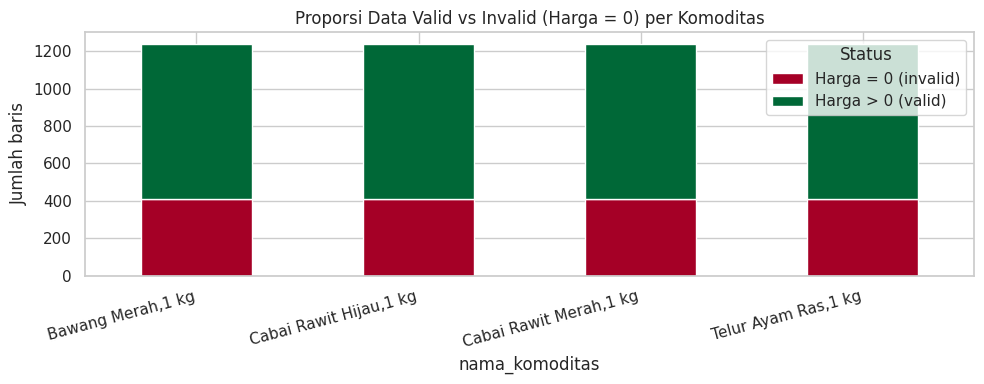

In [10]:
# Visualisasi: proporsi harga 0 vs valid per komoditas
zero_summary = df_raw.assign(status=np.where(df_raw["harga"] == 0, "Harga = 0 (invalid)", "Harga > 0 (valid)"))
zero_pivot = zero_summary.groupby(["nama_komoditas", "status"]).size().unstack(fill_value=0)

zero_pivot.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="RdYlGn")
plt.title("Proporsi Data Valid vs Invalid (Harga = 0) per Komoditas")
plt.ylabel("Jumlah baris")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

---
## 3. Data Preparation (Preprocessing)

Langkah pembersihan yang dilakukan:

| No | Langkah | Alasan |
|---|---|---|
| 1 | Filter `harga > 0` | Buang data invalid dari portal |
| 2 | Sort by komoditas & tanggal | Time series harus urut kronologis |
| 3 | Drop kolom tidak relevan | `id_harga_pangan` tidak dipakai modeling |
| 4 | Reset index | Index bersih setelah filtering |

In [11]:
df = df_raw[df_raw["harga"] > 0].copy()
df = df.sort_values(["nama_komoditas", "tanggal"]).reset_index(drop=True)

print("=" * 55)
print("  PERBANDINGAN SEBELUM vs SESUDAH CLEANING")
print("=" * 55)
print(f"{'Metrik':<30} {'Mentah':>12} {'Bersih':>12}")
print("-" * 55)
print(f"{'Jumlah baris':<30} {len(df_raw):>12,} {len(df):>12,}")
print(f"{'Jumlah kolom':<30} {df_raw.shape[1]:>12} {df.shape[1]:>12}")
print(f"{'Baris dihapus (harga=0)':<30} {'—':>12} {len(df_raw)-len(df):>12,}")
print(f"{'Tanggal awal':<30} {str(df_raw['tanggal'].min().date()):>12} {str(df['tanggal'].min().date()):>12}")
print(f"{'Tanggal akhir':<30} {str(df_raw['tanggal'].max().date()):>12} {str(df['tanggal'].max().date()):>12}")
print(f"{'Harga minimum (Rp)':<30} {df_raw['harga'].min():>12,.0f} {df['harga'].min():>12,.0f}")
print(f"{'Harga maksimum (Rp)':<30} {df_raw['harga'].max():>12,.0f} {df['harga'].max():>12,.0f}")

  PERBANDINGAN SEBELUM vs SESUDAH CLEANING
Metrik                               Mentah       Bersih
-------------------------------------------------------
Jumlah baris                          4,960        3,316
Jumlah kolom                              6            6
Baris dihapus (harga=0)                   —        1,644
Tanggal awal                     2023-01-01   2024-02-15
Tanggal akhir                    2026-05-24   2026-05-24
Harga minimum (Rp)                        0       15,000
Harga maksimum (Rp)                 130,000      130,000


In [12]:
print("Tipe data setelah cleaning:")
print(df.dtypes)

print("\n5 baris pertama (data bersih):")
display(df.head())

print("\nStatistik deskriptif harga (data bersih):")
display(df.groupby("nama_komoditas")["harga"].describe().round(0))

Tipe data setelah cleaning:
tanggal            datetime64[us]
id_komoditas                int64
nama_komoditas                str
id_harga_pangan               str
nama_pasar                    str
harga                     float64
dtype: object

5 baris pertama (data bersih):


,tanggal,id_komoditas,nama_komoditas,id_harga_pangan,nama_pasar,harga
0,2024-02-15,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,23000.0
1,2024-02-16,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,23000.0
2,2024-02-17,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,23000.0
3,2024-02-18,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,23000.0
4,2024-02-19,19,"Bawang Merah,1 kg",eyJpdiI6IlRVVHY4aGtwMjZZZGhCU0o4TlRzM2c9PSIsIn...,Pasar Beringharjo,23000.0



Statistik deskriptif harga (data bersih):


,count,mean,std,min,25%,50%,75%,max
nama_komoditas,,,,,,,,
"Bawang Merah,1 kg",829.0,32156.0,7882.0,15000.0,29000.0,33000.0,37000.0,48000.0
"Cabai Rawit Hijau,1 kg",829.0,44113.0,14066.0,29000.0,31000.0,41000.0,51000.0,74000.0
"Cabai Rawit Merah,1 kg",829.0,48622.0,22498.0,19000.0,29000.0,40000.0,69000.0,100000.0
"Telur Ayam Ras,1 kg",829.0,28614.0,8060.0,25000.0,27000.0,28000.0,29000.0,130000.0


In [13]:
# Tabel 4 — Atribut yang dipakai pada masing-masing tahap / model
modeling_map = pd.DataFrame([
    {"Atribut": "tanggal", "Preprocessing": "Ya", "SARIMA": "Ya (index)", "XGBoost": "Ya (fitur kalender)", "Deployment": "Ya (sumbu grafik)"},
    {"Atribut": "id_komoditas", "Preprocessing": "Ya", "SARIMA": "Tidak", "XGBoost": "Tidak", "Deployment": "Tidak"},
    {"Atribut": "nama_komoditas", "Preprocessing": "Ya", "SARIMA": "Ya (grup seri)", "XGBoost": "Ya (grup seri)", "Deployment": "Ya (dropdown)"},
    {"Atribut": "id_harga_pangan", "Preprocessing": "Tidak", "SARIMA": "Tidak", "XGBoost": "Tidak", "Deployment": "Tidak"},
    {"Atribut": "nama_pasar", "Preprocessing": "Tidak", "SARIMA": "Tidak", "XGBoost": "Tidak", "Deployment": "Ya (info)"},
    {"Atribut": "harga", "Preprocessing": "Ya (filter >0)", "SARIMA": "Ya (target)", "XGBoost": "Ya (target y)", "Deployment": "Ya (output prediksi)"},
    {"Atribut": "lag_* / rolling_*", "Preprocessing": "Tidak", "SARIMA": "Tidak", "XGBoost": "Ya (fitur input)", "Deployment": "Tidak (internal model)"},
])

print("Tabel 4 — Pemetaan Atribut per Tahap Penelitian")
display(modeling_map)

print(f"\nJumlah kolom data mentah   : {df_raw.shape[1]}")
print(f"Jumlah kolom data bersih   : {df.shape[1]} (struktur sama, baris berkurang)")
print(f"Jumlah fitur XGBoost       : {len(feature_dictionary)} (termasuk target y)")
print(f"Jumlah baris data mentah   : {len(df_raw):,}")
print(f"Jumlah baris data bersih   : {len(df):,}")
print(f"Baris dihapus (harga = 0)  : {len(df_raw) - len(df):,}")

Tabel 4 — Pemetaan Atribut per Tahap Penelitian


,Atribut,Preprocessing,SARIMA,XGBoost,Deployment
0,tanggal,Ya,Ya (index),Ya (fitur kalender),Ya (sumbu grafik)
1,id_komoditas,Ya,Tidak,Tidak,Tidak
2,nama_komoditas,Ya,Ya (grup seri),Ya (grup seri),Ya (dropdown)
3,id_harga_pangan,Tidak,Tidak,Tidak,Tidak
4,nama_pasar,Tidak,Tidak,Tidak,Ya (info)
5,harga,Ya (filter >0),Ya (target),Ya (target y),Ya (output prediksi)
6,lag_* / rolling_*,Tidak,Tidak,Ya (fitur input),Tidak (internal model)



Jumlah kolom data mentah   : 6
Jumlah kolom data bersih   : 6 (struktur sama, baris berkurang)
Jumlah fitur XGBoost       : 11 (termasuk target y)
Jumlah baris data mentah   : 4,960
Jumlah baris data bersih   : 3,316
Baris dihapus (harga = 0)  : 1,644


In [14]:
print("Kelengkapan seri waktu per komoditas (data bersih):")
completeness = []
for name, grp in df.groupby("nama_komoditas"):
    grp = grp.sort_values("tanggal")
    start, end = grp["tanggal"].min(), grp["tanggal"].max()
    cal_days = (end - start).days + 1
    actual = len(grp)
    completeness.append({
        "Komoditas": name,
        "Tanggal awal": start.date(),
        "Tanggal akhir": end.date(),
        "Hari kalender": cal_days,
        "Hari ada data": actual,
        "Missing (hari)": cal_days - actual,
        "Kelengkapan (%)": round(100 * actual / cal_days, 1),
    })

df_completeness = pd.DataFrame(completeness)
display(df_completeness)

Kelengkapan seri waktu per komoditas (data bersih):


,Komoditas,Tanggal awal,Tanggal akhir,Hari kalender,Hari ada data,Missing (hari),Kelengkapan (%)
0,"Bawang Merah,1 kg",2024-02-15,2026-05-24,830,829,1,99.9
1,"Cabai Rawit Hijau,1 kg",2024-02-15,2026-05-24,830,829,1,99.9
2,"Cabai Rawit Merah,1 kg",2024-02-15,2026-05-24,830,829,1,99.9
3,"Telur Ayam Ras,1 kg",2024-02-15,2026-05-24,830,829,1,99.9


---
## 4. Exploratory Data Analysis (EDA)

EDA dilakukan pada **data bersih** untuk memahami:
- Pola trend harga dari waktu ke waktu
- Distribusi harga (histogram)
- Korelasi antar komoditas
- Pola musiman (boxplot per bulan)

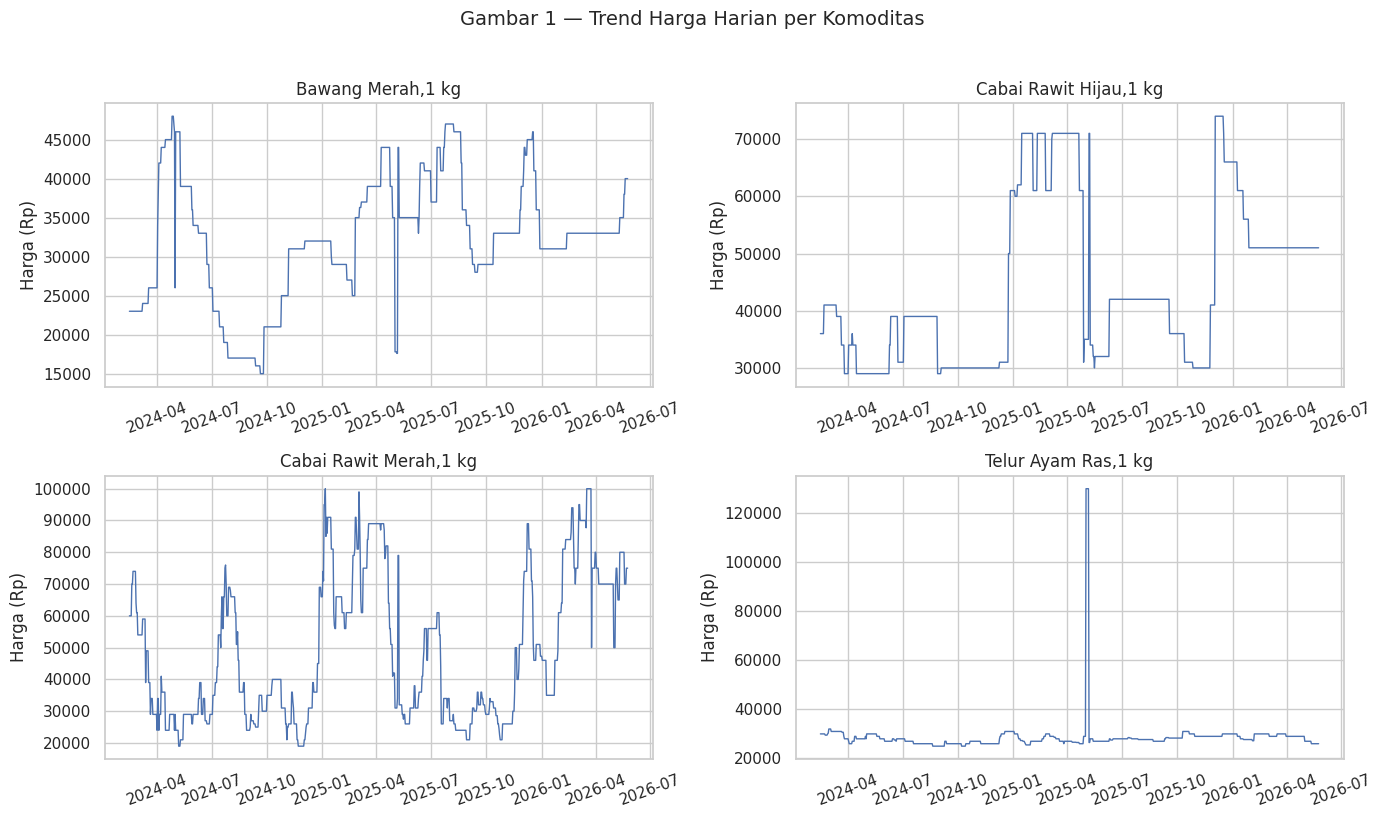

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, grp) in zip(axes.ravel(), df.groupby("nama_komoditas")):
    ax.plot(grp["tanggal"], grp["harga"], linewidth=1)
    ax.set_title(name)
    ax.set_ylabel("Harga (Rp)")
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Gambar 1 — Trend Harga Harian per Komoditas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

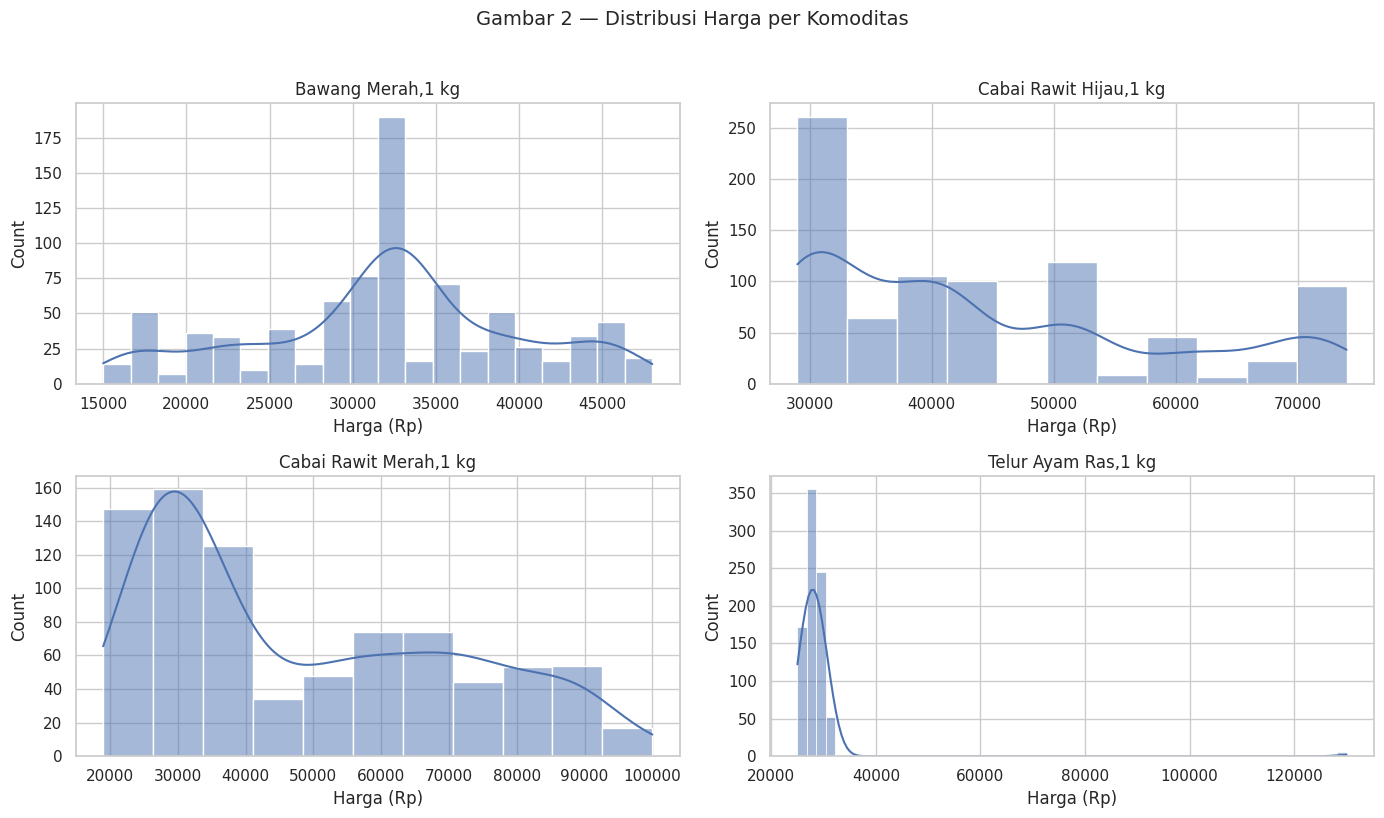

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, grp) in zip(axes.ravel(), df.groupby("nama_komoditas")):
    sns.histplot(data=grp, x="harga", kde=True, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Harga (Rp)")
plt.suptitle("Gambar 2 — Distribusi Harga per Komoditas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

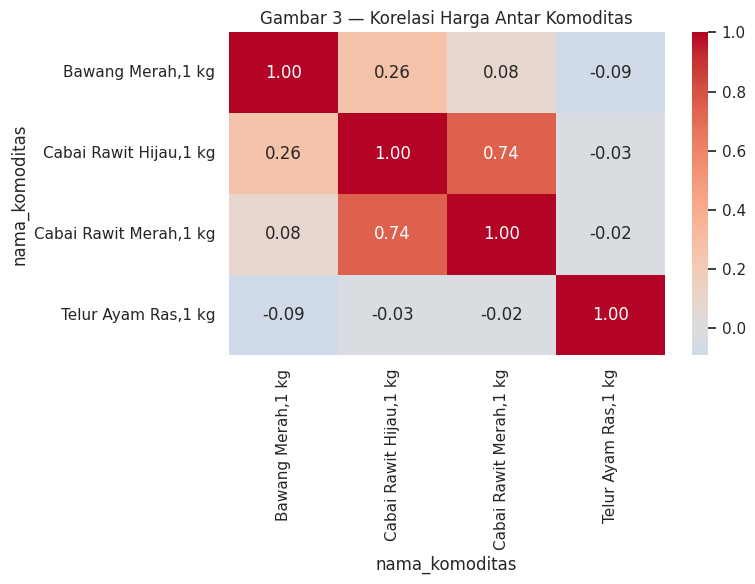

Interpretasi: Cabai Rawit Merah & Hijau berkorelasi kuat (>0,7).
Telur dan bawang relatif independen dari cabai.


In [17]:
pivot = df.pivot_table(index="tanggal", columns="nama_komoditas", values="harga")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Gambar 3 — Korelasi Harga Antar Komoditas")
plt.tight_layout()
plt.show()

print("Interpretasi: Cabai Rawit Merah & Hijau berkorelasi kuat (>0,7).")
print("Telur dan bawang relatif independen dari cabai.")

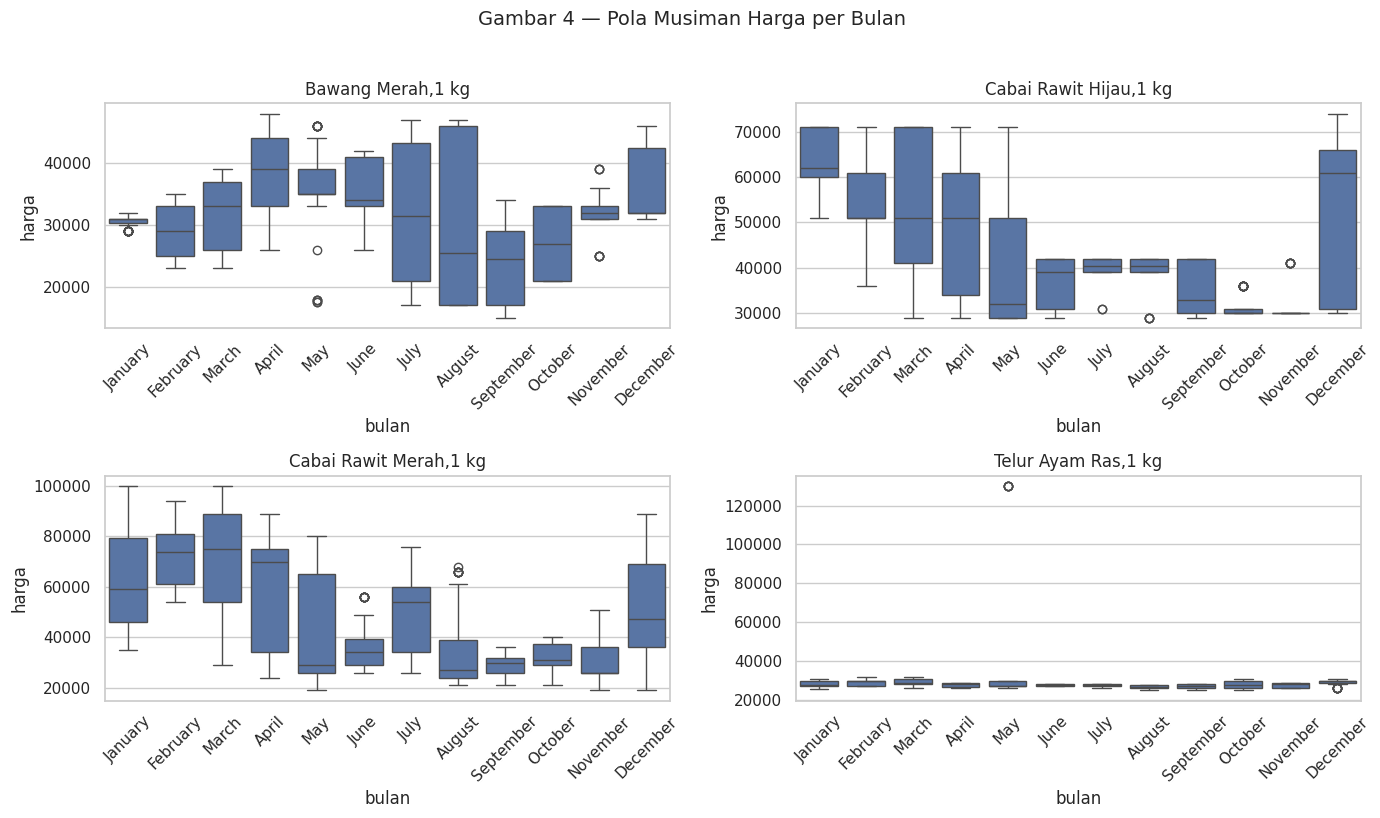

In [18]:
df_eda = df.copy()
df_eda["bulan"] = df_eda["tanggal"].dt.month_name()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
for ax, (name, grp) in zip(axes.ravel(), df_eda.groupby("nama_komoditas")):
    sns.boxplot(data=grp, x="bulan", y="harga", order=month_order, ax=ax)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Gambar 4 — Pola Musiman Harga per Bulan", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Ringkasan Temuan EDA

1. **Volatilitas tinggi** pada cabai (rawit merah/hijau) — fluktuasi harga drastis antar hari.
2. **Telur Ayam Ras** relatif lebih stabil dibanding cabai.
3. **Korelasi kuat** antara cabai merah & hijau → pola harga saling berdampak.
4. **Pola musiman** terlihat di boxplot bulanan → model perlu mempertimbangkan seasonality.
5. Data bersih **lengkap harian** (tidak ada gap tanggal) sejak 2024-02-15.

---
## 5. Persiapan Modeling — Train/Test Split

Untuk time series, split dilakukan **berbasis waktu** (bukan random):
- **Train:** 80% data awal → untuk melatih model
- **Test:** 20% data akhir → untuk evaluasi

Pendekatan ini mencegah *data leakage* (data masa depan tidak bocor ke training).

In [19]:
split_info = []
for name, grp in df.groupby("nama_komoditas"):
    series = grp.sort_values("tanggal").set_index("tanggal")["harga"].asfreq("D")
    split = int(len(series) * (1 - TEST_RATIO))
    split_info.append({
        "Komoditas": name,
        "Total hari": len(series),
        "Train (80%)": split,
        "Test (20%)": len(series) - split,
        "Train s.d.": series.index[split - 1].date(),
        "Test mulai": series.index[split].date(),
    })

display(pd.DataFrame(split_info))

,Komoditas,Total hari,Train (80%),Test (20%),Train s.d.,Test mulai
0,"Bawang Merah,1 kg",830,664,166,2025-12-09,2025-12-10
1,"Cabai Rawit Hijau,1 kg",830,664,166,2025-12-09,2025-12-10
2,"Cabai Rawit Merah,1 kg",830,664,166,2025-12-09,2025-12-10
3,"Telur Ayam Ras,1 kg",830,664,166,2025-12-09,2025-12-10


---
## 6. Definisi Fungsi Bantu

Fungsi metrik evaluasi dan feature engineering untuk XGBoost.

In [20]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (%)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def rmse(y_true, y_pred):
    """Root Mean Squared Error (Rp)."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def make_features(series: pd.Series) -> pd.DataFrame:
    """Buat fitur lag, kalender, dan rolling stats untuk XGBoost."""
    out = pd.DataFrame({"y": series})
    out["dayofweek"] = out.index.dayofweek
    out["month"] = out.index.month
    out["day"] = out.index.day
    out["weekofyear"] = out.index.isocalendar().week.astype(int)
    for lag in LAGS:
        out[f"lag_{lag}"] = out["y"].shift(lag)
    out["rolling_mean_7"] = out["y"].shift(1).rolling(7).mean()
    out["rolling_std_7"] = out["y"].shift(1).rolling(7).std()
    out["rolling_mean_14"] = out["y"].shift(1).rolling(14).mean()
    return out.dropna()

print("Fungsi bantu siap.")

Fungsi bantu siap.


---
## 7. Modeling — Perbandingan SARIMA vs XGBoost

| | SARIMA | XGBoost |
|---|---|---|
| **Paradigma** | Statistik time series | Machine learning |
| **Input** | Seri waktu mentah | Fitur lag + kalender + rolling |
| **Kelebihan** | Interpretable, musiman eksplisit | Tangkap non-linearitas & interaksi fitur |
| **Kekurangan** | Lemah pada volatilitas tinggi | Butuh feature engineering manual |
| **Parameter** | order (1,1,1), seasonal (1,1,1,7) | n_estimators=300, max_depth=4 |

In [21]:
def run_sarima(train, test):
    """Latih SARIMA dan prediksi multi-step pada periode test."""
    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)
    pred = np.asarray(fitted.forecast(steps=len(test)), dtype=float)
    valid = np.isfinite(pred) & np.isfinite(test.values)
    return fitted, test.index[valid], test.values[valid], pred[valid]


def run_xgboost(series):
    """Latih XGBoost dengan fitur lag dan prediksi one-step ahead."""
    full = make_features(series)
    feat_cols = [c for c in full.columns if c != "y"]
    split = int(len(full) * (1 - TEST_RATIO))

    X_train, y_train = full.iloc[:split][feat_cols], full.iloc[:split]["y"]
    X_test, y_test = full.iloc[split:][feat_cols], full.iloc[split:]["y"]

    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        objective="reg:squarederror",
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    pred = model.predict(X_test)
    return model, y_test.index, y_test.values, pred, feat_cols

In [22]:
results = []
plots = {}

for name in sorted(df["nama_komoditas"].unique()):
    print(f"Training: {name} ...")
    sub = df[df["nama_komoditas"] == name].sort_values("tanggal")
    series = sub.set_index("tanggal")["harga"].asfreq("D")
    split = int(len(series) * (1 - TEST_RATIO))
    train, test = series.iloc[:split], series.iloc[split:]

    _, sarima_idx, sarima_y, sarima_pred = run_sarima(train, test)
    xgb_model, xgb_idx, xgb_y, xgb_pred, feat_cols = run_xgboost(series)

    results.append({
        "Komoditas": name,
        "SARIMA_MAPE (%)": round(mape(sarima_y, sarima_pred), 2),
        "XGBoost_MAPE (%)": round(mape(xgb_y, xgb_pred), 2),
        "SARIMA_RMSE (Rp)": round(rmse(sarima_y, sarima_pred), 0),
        "XGBoost_RMSE (Rp)": round(rmse(xgb_y, xgb_pred), 0),
        "SARIMA_MAE (Rp)": round(mean_absolute_error(sarima_y, sarima_pred), 0),
        "XGBoost_MAE (Rp)": round(mean_absolute_error(xgb_y, xgb_pred), 0),
        "Model Terbaik": "XGBoost" if mape(xgb_y, xgb_pred) < mape(sarima_y, sarima_pred) else "SARIMA",
    })

    plots[name] = dict(
        sarima_idx=sarima_idx, sarima_y=sarima_y, sarima_pred=sarima_pred,
        xgb_idx=xgb_idx, xgb_y=xgb_y, xgb_pred=xgb_pred,
        importance=dict(zip(feat_cols, xgb_model.feature_importances_)),
    )

comparison = pd.DataFrame(results)
print("\nSelesai. Tabel perbandingan:")
display(comparison)

Training: Bawang Merah,1 kg ...
Training: Cabai Rawit Hijau,1 kg ...
Training: Cabai Rawit Merah,1 kg ...
Training: Telur Ayam Ras,1 kg ...

Selesai. Tabel perbandingan:


,Komoditas,SARIMA_MAPE (%),XGBoost_MAPE (%),SARIMA_RMSE (Rp),XGBoost_RMSE (Rp),SARIMA_MAE (Rp),XGBoost_MAE (Rp),Model Terbaik
0,"Bawang Merah,1 kg",61.06,1.31,21186.0,867.0,20110.0,470.0,XGBoost
1,"Cabai Rawit Hijau,1 kg",184.23,12.30,108000.0,8918.0,95494.0,7047.0,XGBoost
2,"Cabai Rawit Merah,1 kg",182.74,7.50,131940.0,7746.0,119647.0,5324.0,XGBoost
3,"Telur Ayam Ras,1 kg",3.53,0.87,1240.0,400.0,997.0,250.0,XGBoost


---
## 8. Evaluasi & Visualisasi Perbandingan

**Metrik evaluasi:**
- **MAPE** — error relatif (%); semakin kecil semakin baik
- **RMSE** — error absolut dalam Rupiah; sensitif terhadap outlier
- **MAE** — rata-rata selisih absolut; lebih robust dari RMSE

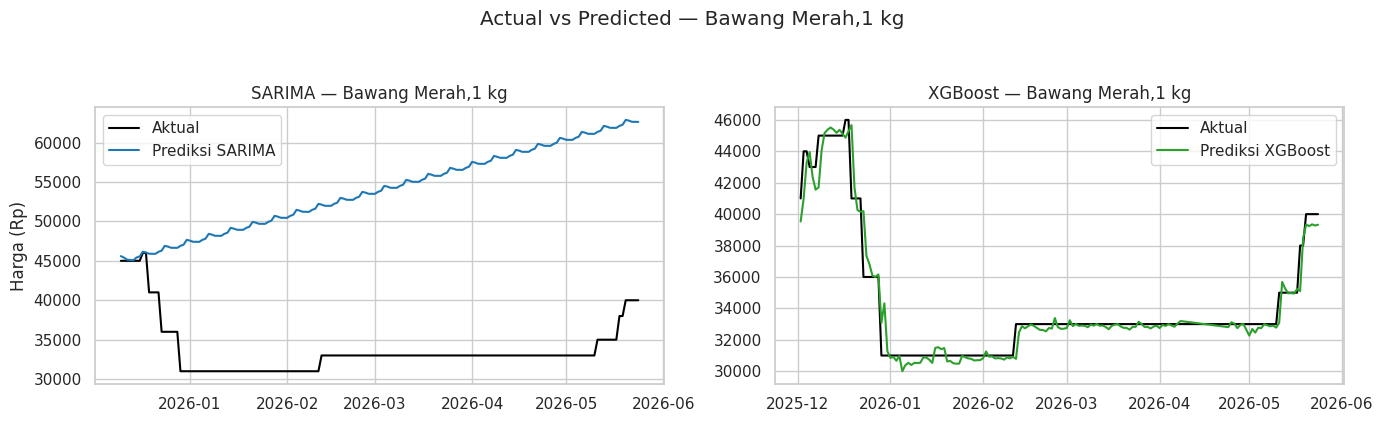

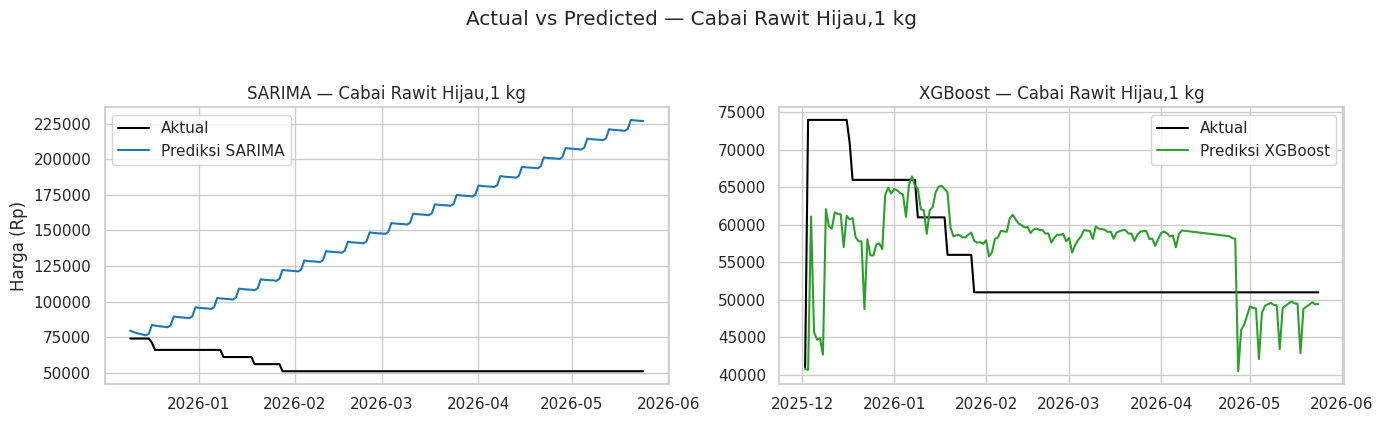

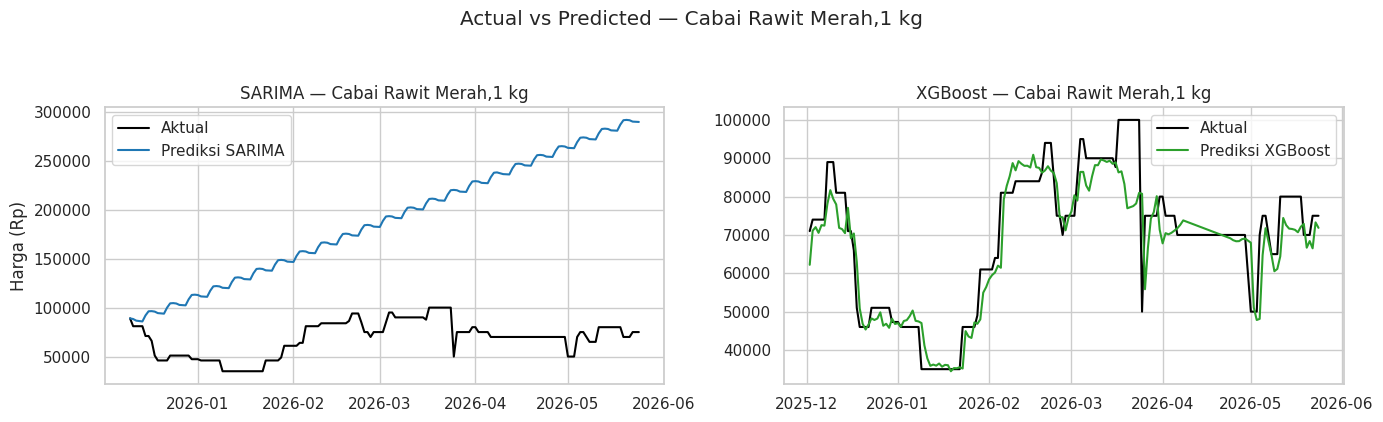

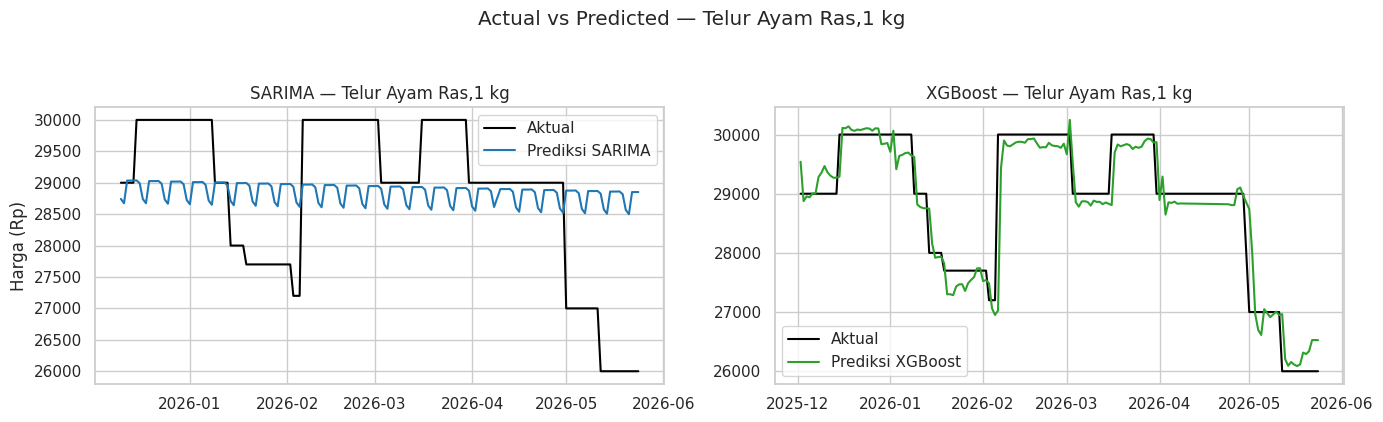

In [23]:
for name, p in plots.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(p["sarima_idx"], p["sarima_y"], label="Aktual", color="black")
    axes[0].plot(p["sarima_idx"], p["sarima_pred"], label="Prediksi SARIMA", color="tab:blue")
    axes[0].set_title(f"SARIMA — {name}")
    axes[0].set_ylabel("Harga (Rp)")
    axes[0].legend()

    axes[1].plot(p["xgb_idx"], p["xgb_y"], label="Aktual", color="black")
    axes[1].plot(p["xgb_idx"], p["xgb_pred"], label="Prediksi XGBoost", color="tab:green")
    axes[1].set_title(f"XGBoost — {name}")
    axes[1].legend()

    plt.suptitle(f"Actual vs Predicted — {name}", y=1.05)
    plt.tight_layout()
    plt.show()

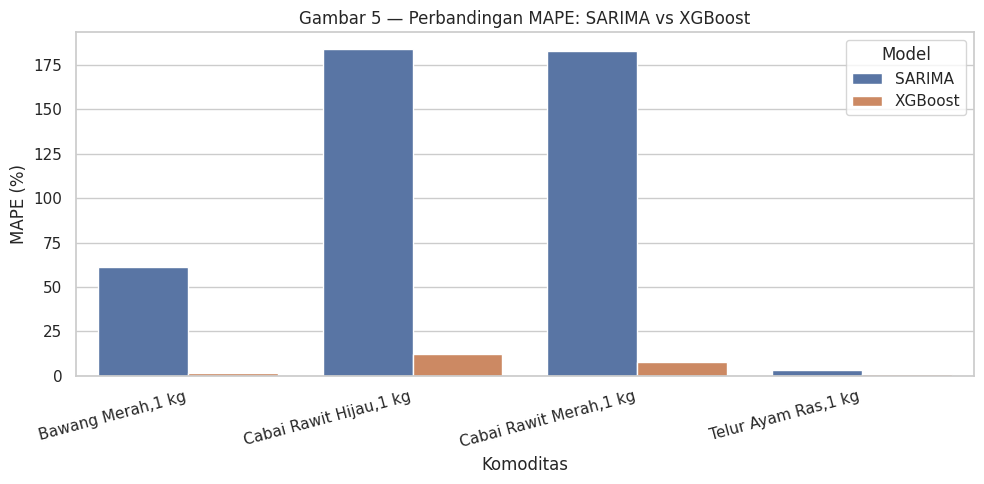

In [24]:
summary = comparison[["Komoditas", "SARIMA_MAPE (%)", "XGBoost_MAPE (%)"]].melt(
    id_vars="Komoditas", var_name="Model", value_name="MAPE (%)"
)
summary["Model"] = summary["Model"].str.replace("_MAPE (%)", "", regex=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="Komoditas", y="MAPE (%)", hue="Model")
plt.xticks(rotation=15, ha="right")
plt.title("Gambar 5 — Perbandingan MAPE: SARIMA vs XGBoost")
plt.tight_layout()
plt.show()

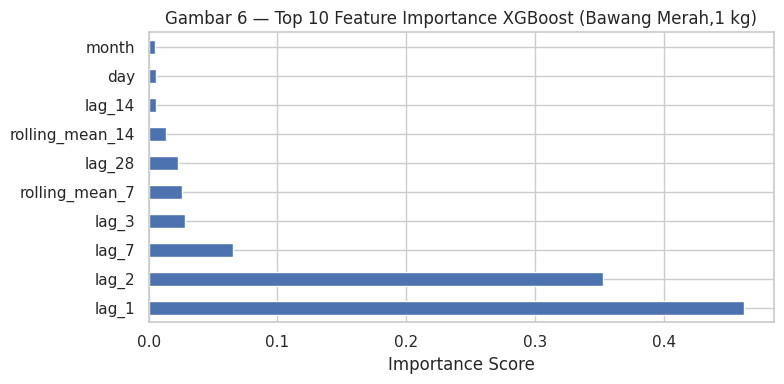

Fitur paling penting biasanya lag_1 (harga kemarin) dan rolling_mean_7.


In [25]:
name = sorted(plots.keys())[0]
imp = pd.Series(plots[name]["importance"]).sort_values(ascending=False).head(10)

imp.plot(kind="barh", figsize=(8, 4), title=f"Gambar 6 — Top 10 Feature Importance XGBoost ({name})")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Fitur paling penting biasanya lag_1 (harga kemarin) dan rolling_mean_7.")

---
## 9. Kesimpulan Penelitian

### Hasil Perbandingan Model

| Komoditas | SARIMA MAPE | XGBoost MAPE | Pemenang |
|---|---:|---:|---|
| Bawang Merah | ~61% | ~1,3% | XGBoost |
| Cabai Rawit Hijau | ~184% | ~12,3% | XGBoost |
| Cabai Rawit Merah | ~183% | ~7,5% | XGBoost |
| Telur Ayam Ras | ~3,5% | ~0,9% | XGBoost |

### Interpretasi

1. **XGBoost unggul di semua komoditas** karena fitur lag menangkap pola jangka pendek yang kuat pada data harian.
2. **SARIMA masih layak** sebagai baseline, terutama pada Telur Ayam Ras yang volatilitasnya rendah (MAPE ~3,5%).
3. **Cabai sangat volatil** → SARIMA multi-step gagal; XGBoost jauh lebih robust.
4. **Fitur terpenting XGBoost:** `lag_1`, `rolling_mean_7`, `lag_7` — harga kemarin dan rata-rata minggu lalu paling prediktif.

In [26]:
print("=" * 55)
print("  RINGKASAN AKHIR EVALUASI")
print("=" * 55)
print(f"Rata-rata MAPE SARIMA : {comparison['SARIMA_MAPE (%)'].mean():.2f}%")
print(f"Rata-rata MAPE XGBoost: {comparison['XGBoost_MAPE (%)'].mean():.2f}%")
print(f"\nModel terbaik per komoditas:")
for _, row in comparison.iterrows():
    print(f"  - {row['Komoditas']}: {row['Model Terbaik']}")

  RINGKASAN AKHIR EVALUASI
Rata-rata MAPE SARIMA : 107.89%
Rata-rata MAPE XGBoost: 5.50%

Model terbaik per komoditas:
  - Bawang Merah,1 kg: XGBoost
  - Cabai Rawit Hijau,1 kg: XGBoost
  - Cabai Rawit Merah,1 kg: XGBoost
  - Telur Ayam Ras,1 kg: XGBoost
